# 06 — Enhanced Features & External Data

The v2 model uses 43 features and achieves R² = 0.016 with predictions maxing out ~7.4 points.
The FPL API provides ~15 unused fields per gameweek (tackles, recoveries, starts, opponent_team, match scores, etc.)
and previous season data (`history_past`). We'll exploit these plus external data to build a v3 model.

**Phases:**
1. Exploit unused FPL API data (~35 new features)
2. Historical data from vaastav GitHub repo (multi-season H2H)
3. FBref advanced stats (touches, progressive passes, SCA)

In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

plt.style.use('ggplot')
pd.set_option('display.max_columns', 80)

## 1. Build enhanced feature set

The refactored `build_features()` now computes ~70 features including rolling defensive stats,
team strength, head-to-head, transfer momentum, and previous season baselines.

In [2]:
from src.fpl.predict import build_features, get_feature_columns

gw_df = build_features()
print(f'Total gameweek records: {len(gw_df):,}')
print(f'Unique players: {gw_df["player_id"].nunique()}')
print(f'Gameweek range: {gw_df["round"].min()} - {gw_df["round"].max()}')

v3_features = get_feature_columns()
v3_features = [c for c in v3_features if c in gw_df.columns]
print(f'\nTotal v3 features: {len(v3_features)}')

v2_feature_names = [
    'pts_roll3', 'pts_roll5', 'min_roll3', 'min_roll5', 'goals_roll3', 'goals_roll5',
    'ast_roll3', 'ast_roll5', 'bonus_roll3', 'bonus_roll5', 'bps_roll3', 'bps_roll5',
    'xg_roll3', 'xg_roll5', 'xa_roll3', 'xa_roll5', 'xgi_roll3', 'xgi_roll5',
    'xgc_roll3', 'xgc_roll5', 'cs_roll3', 'cs_roll5', 'infl_roll3', 'infl_roll5',
    'crea_roll3', 'crea_roll5', 'thrt_roll3', 'thrt_roll5', 'ict_roll3', 'ict_roll5',
    'pts_season_avg', 'min_season_avg', 'xg_season_avg', 'xa_season_avg', 'bonus_season_avg',
    'was_home', 'fdr', 'price', 'price_change_1gw', 'price_change_3gw', 'rest_days',
    'games_played', 'element_type'
]
new_features = [f for f in v3_features if f not in v2_feature_names]
print(f'New features beyond v2 ({len(new_features)}): {new_features}')

Total gameweek records: 22,501
Unique players: 820
Gameweek range: 1 - 29

Total v3 features: 70
New features beyond v2 (27): ['starts_roll3', 'starts_roll5', 'tackles_roll3', 'tackles_roll5', 'recov_roll3', 'recov_roll5', 'yc_roll3', 'yc_roll5', 'saves_roll3', 'saves_roll5', 'starts_season_avg', 'def_actions_roll3', 'def_actions_roll5', 'team_goals_for_roll5', 'team_goals_against_roll5', 'h2h_avg_pts', 'h2h_avg_xg', 'h2h_games', 'transfers_balance_roll3', 'log_selected', 'prev_season_pts_per90', 'prev_season_xg_per90', 'prev_season_minutes', 'h2h_prev_season_avg_pts', 'h2h_prev_season_games', 'xg_improvement', 'pts_improvement']


## 2. New feature correlation analysis

Check which new features correlate most with `total_points`.

In [3]:
played = gw_df[gw_df['minutes'] > 0].copy()

corr = played[v3_features + ['target']].corr()['target'].drop('target', errors='ignore')
corr = corr.dropna().sort_values(ascending=False)

print('Top 20 features by correlation with total_points:')
print(corr.head(20).to_string())
print('\nBottom 10:')
print(corr.tail(10).to_string())

Top 20 features by correlation with total_points:
h2h_prev_season_games    0.235255
min_roll3                0.227837
min_season_avg           0.221197
min_roll5                0.220066
pts_season_avg           0.215220
log_selected             0.214763
starts_roll3             0.213345
starts_season_avg        0.212550
ict_roll5                0.210168
starts_roll5             0.208866
infl_roll5               0.205219
ict_roll3                0.205106
pts_roll5                0.197261
bps_roll5                0.195218
infl_roll3               0.194508
pts_roll3                0.183181
bps_roll3                0.180857
def_actions_roll5        0.176578
def_actions_roll3        0.175870
xgi_roll5                0.163193

Bottom 10:
saves_roll5                 0.021457
games_played                0.008612
h2h_games                   0.007055
rest_days                   0.003809
xg_improvement             -0.000629
prev_season_pts_per90      -0.006778
team_goals_against_roll5   -0.018403

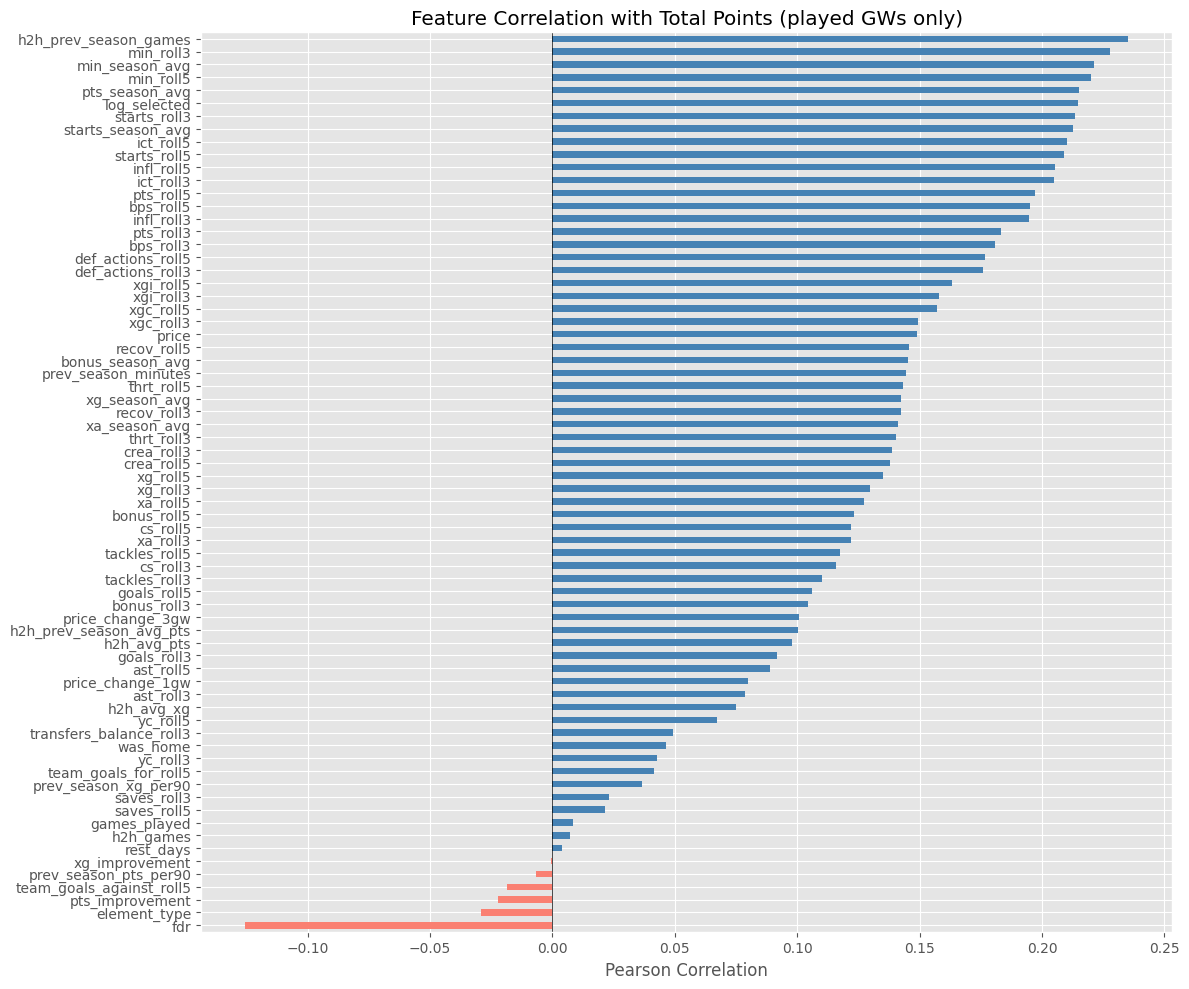

In [4]:
fig, ax = plt.subplots(figsize=(12, 10))
corr.sort_values().plot.barh(ax=ax, color=np.where(corr.sort_values() > 0, 'steelblue', 'salmon'))
ax.set_title('Feature Correlation with Total Points (played GWs only)')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 3. Head-to-head deep dive

Examine H2H features — do players perform consistently against specific opponents?

In [5]:
h2h_data = played.dropna(subset=['h2h_avg_pts'])
print(f'Rows with H2H data: {len(h2h_data):,} ({len(h2h_data)/len(played)*100:.1f}% of played GWs)')
print(f'\nH2H avg pts distribution:')
print(h2h_data['h2h_avg_pts'].describe())

top_h2h = (h2h_data.groupby(['web_name', 'opponent_team'])
           .agg(h2h_pts=('h2h_avg_pts', 'last'), games=('h2h_games', 'last'))
           .reset_index())
top_h2h = top_h2h[top_h2h['games'] >= 2].sort_values('h2h_pts', ascending=False)
print('\nTop H2H records (min 2 prior games):')
print(top_h2h.head(15).to_string())

Rows with H2H data: 2,908 (32.8% of played GWs)

H2H avg pts distribution:
count    2908.000000
mean        2.371561
std         3.012803
min        -3.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        24.000000
Name: h2h_avg_pts, dtype: float64

Top H2H records (min 2 prior games):
           web_name  opponent_team  h2h_pts  games
1024          Guéhi             10      5.0    2.0
2293        Semenyo             18      4.0    2.0
799             Eze             16      3.0    2.0
797             Eze              7      2.5    2.0
914          George             10      1.5    2.0
38            Adama              7      1.0    2.0
891        Garnacho              1      0.5    2.0
2228         Sancho              1      0.5    2.0
2381  Strand Larsen             14      0.5    2.0
309            Bobb             17      0.0    2.0
405      Buonanotte              9      0.0    2.0
913          George              4      0.0    2.0
1974  Ortega Moreno   

## 4. Train/test split and v2 baseline

Same split as v2: GW 4-22 train, GW 23-29 test. Played-only rows.

In [6]:
with open(project_root / 'models' / 'model_metadata.json') as f:
    v2_meta = json.load(f)
v2_features = v2_meta['feature_columns']

train_gws = range(4, 23)
test_gws = range(23, 30)

train = played[played['round'].isin(train_gws)].copy()
test = played[played['round'].isin(test_gws)].copy()

print(f'Train: {len(train):,} rows (GW 4-22)')
print(f'Test: {len(test):,} rows (GW 23-29)')

v2_model = joblib.load(project_root / 'models' / 'best_model.joblib')
v2_preds = v2_model.predict(test[v2_features].fillna(0))
v2_mae = mean_absolute_error(test['target'], v2_preds)
v2_rmse = root_mean_squared_error(test['target'], v2_preds)
v2_r2 = r2_score(test['target'], v2_preds)
print(f'\nv2 baseline — MAE: {v2_mae:.3f}, RMSE: {v2_rmse:.3f}, R²: {v2_r2:.4f}')
print(f'v2 prediction range: {v2_preds.min():.2f} to {v2_preds.max():.2f}')

Train: 5,753 rows (GW 4-22)
Test: 2,198 rows (GW 23-29)

v2 baseline — MAE: 2.159, RMSE: 2.851, R²: 0.0580
v2 prediction range: 1.15 to 7.34


## 5. Train XGBoost v3 with enhanced features

In [7]:
X_train = train[v3_features]
y_train = train['target']
X_test = test[v3_features]
y_test = test['target']

print(f'Feature matrix: {X_train.shape[1]} features')
print(f'NaN counts in train (top 10):')
print(X_train.isna().sum().sort_values(ascending=False).head(10))

v3_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    enable_categorical=False,
)

v3_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

v3_preds = v3_model.predict(X_test)
v3_mae = mean_absolute_error(y_test, v3_preds)
v3_rmse = root_mean_squared_error(y_test, v3_preds)
v3_r2 = r2_score(y_test, v3_preds)

print(f'\n=== v3 Results ===')
print(f'MAE: {v3_mae:.3f} (v2: {v2_mae:.3f})')
print(f'RMSE: {v3_rmse:.3f} (v2: {v2_rmse:.3f})')
print(f'R²: {v3_r2:.4f} (v2: {v2_r2:.4f})')
print(f'Prediction range: {v3_preds.min():.2f} to {v3_preds.max():.2f}')

Feature matrix: 70 features
NaN counts in train (top 10):
h2h_prev_season_games      5726
h2h_prev_season_avg_pts    5726
h2h_avg_xg                 4899
h2h_avg_pts                4899
pts_improvement            1484
xg_improvement             1484
prev_season_xg_per90       1429
prev_season_minutes        1429
prev_season_pts_per90      1429
price_change_3gw             71
dtype: int64


[0]	validation_0-rmse:2.92806


[50]	validation_0-rmse:2.85732


[100]	validation_0-rmse:2.87945


[150]	validation_0-rmse:2.88799


[200]	validation_0-rmse:2.89907


[250]	validation_0-rmse:2.90863


[299]	validation_0-rmse:2.92413



=== v3 Results ===
MAE: 2.254 (v2: 2.159)
RMSE: 2.924 (v2: 2.851)
R²: 0.0087 (v2: 0.0580)
Prediction range: 0.93 to 9.15


## 6. Feature importance comparison: v2 vs v3

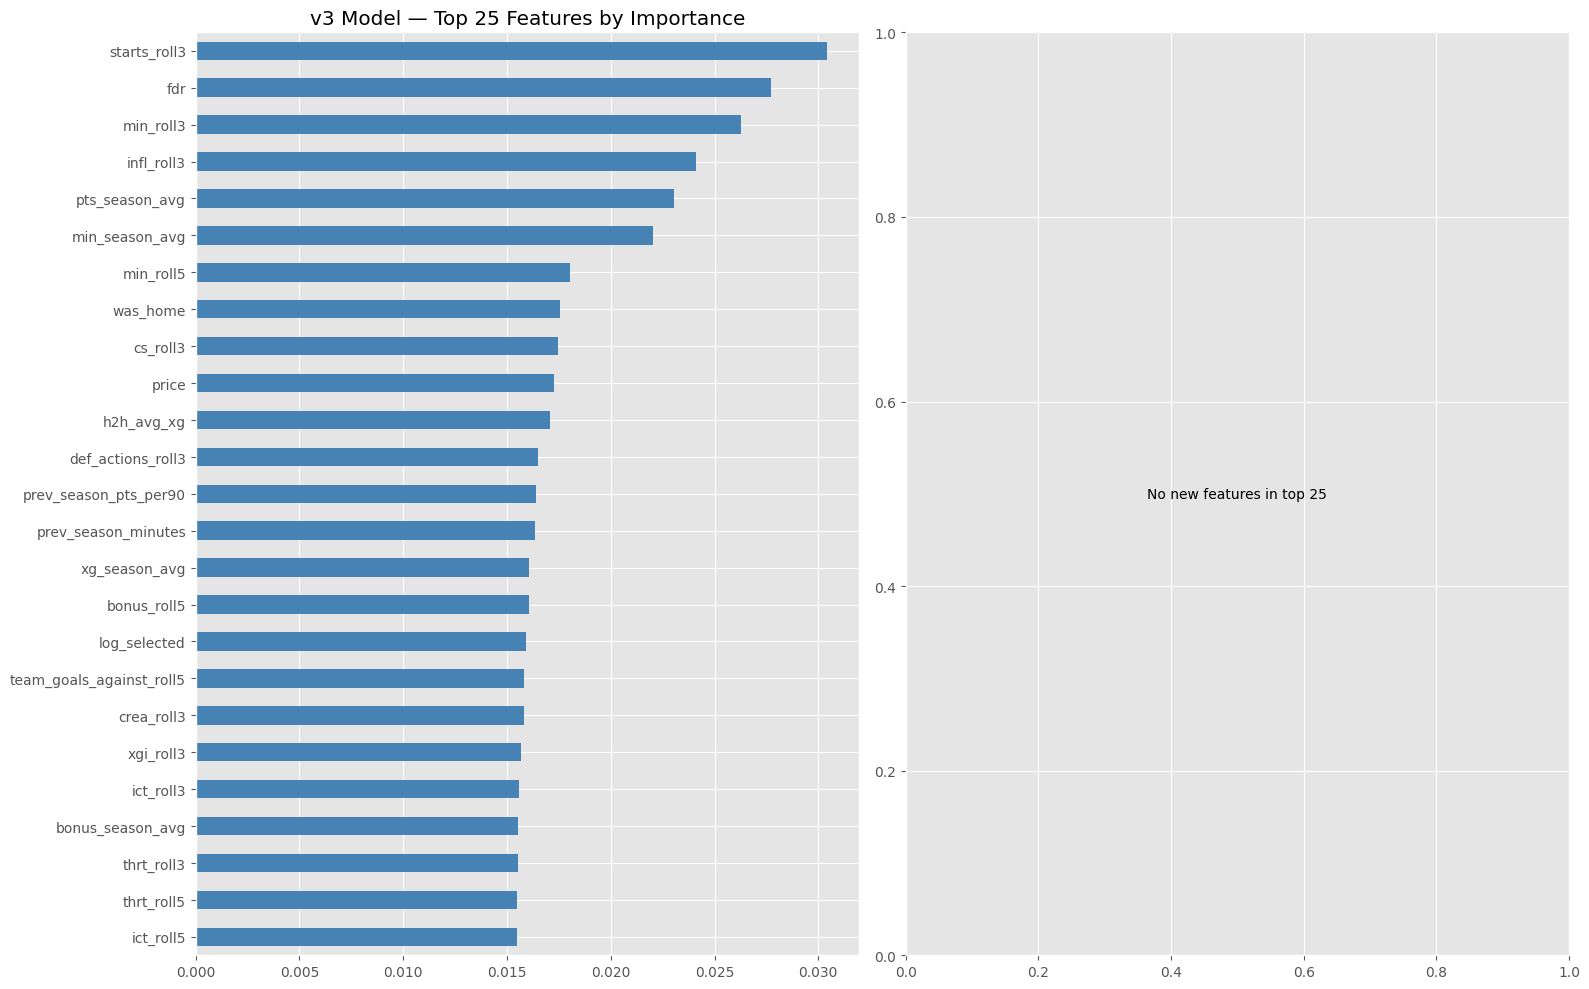


New features in top 25: 0
Full importance ranking:
starts_roll3                0.030440
fdr                         0.027740
min_roll3                   0.026295
infl_roll3                  0.024126
pts_season_avg              0.023030
min_season_avg              0.022055
min_roll5                   0.018040
was_home                    0.017568
cs_roll3                    0.017450
price                       0.017275
h2h_avg_xg                  0.017089
def_actions_roll3           0.016472
prev_season_pts_per90       0.016375
prev_season_minutes         0.016328
xg_season_avg               0.016069
bonus_roll5                 0.016059
log_selected                0.015907
team_goals_against_roll5    0.015799
crea_roll3                  0.015797
xgi_roll3                   0.015673
ict_roll3                   0.015598
bonus_season_avg            0.015544
thrt_roll3                  0.015528
thrt_roll5                  0.015485
ict_roll5                   0.015485
pts_improvement        

In [8]:
importance = pd.Series(v3_model.feature_importances_, index=v3_features)
importance = importance.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

importance.head(25).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('v3 Model — Top 25 Features by Importance')
axes[0].invert_yaxis()

new_feats = [f for f in importance.head(25).index if f not in v2_features]
if new_feats:
    axes[1].barh(range(len(new_feats)), [importance[f] for f in new_feats], color='green', label='New (Phase 1-3)')
    axes[1].set_yticks(range(len(new_feats)))
    axes[1].set_yticklabels(new_feats)
    axes[1].set_title('New Features in Top 25')
    axes[1].invert_yaxis()
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No new features in top 25', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

print(f'\nNew features in top 25: {len(new_feats)}')
print('Full importance ranking:')
print(importance.to_string())

## 7. Ablation study — which feature groups help most?

Train with different feature subsets to see marginal contribution.

In [9]:
feature_groups = {
    'v2 baseline': v2_features,
    '+ defensive': v2_features + [c for c in v3_features if 'def_actions' in c or 'tackles' in c or 'recov' in c or 'saves' in c or 'yc' in c or 'starts' in c],
    '+ team strength': v2_features + [c for c in v3_features if 'team_goals' in c],
    '+ head-to-head': v2_features + [c for c in v3_features if 'h2h' in c],
    '+ transfers': v2_features + [c for c in v3_features if 'transfers_balance' in c or 'log_selected' in c],
    '+ prev season': v2_features + [c for c in v3_features if 'prev_season' in c],
    '+ trajectory': v2_features + [c for c in v3_features if 'improvement' in c],
    'All v3': v3_features,
}

ablation_results = []
for name, feats in feature_groups.items():
    feats = [f for f in feats if f in gw_df.columns]
    feats = list(dict.fromkeys(feats))
    m = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=42)
    m.fit(train[feats], y_train, verbose=0)
    preds = m.predict(test[feats])
    ablation_results.append({
        'group': name,
        'n_features': len(feats),
        'MAE': round(mean_absolute_error(y_test, preds), 3),
        'RMSE': round(root_mean_squared_error(y_test, preds), 3),
        'R2': round(r2_score(y_test, preds), 4),
        'pred_range': f'{preds.min():.2f} - {preds.max():.2f}',
    })

ablation_df = pd.DataFrame(ablation_results)
print(ablation_df.to_string(index=False))

          group  n_features   MAE  RMSE     R2  pred_range
    v2 baseline          68 2.222 2.891 0.0311 0.90 - 9.00
    + defensive          68 2.222 2.891 0.0311 0.90 - 9.00
+ team strength          68 2.222 2.891 0.0311 0.90 - 9.00
 + head-to-head          68 2.222 2.891 0.0311 0.90 - 9.00
    + transfers          68 2.222 2.891 0.0311 0.90 - 9.00
  + prev season          68 2.222 2.891 0.0311 0.90 - 9.00
   + trajectory          70 2.254 2.920 0.0114 1.11 - 8.21
         All v3          70 2.230 2.911 0.0179 0.97 - 8.35


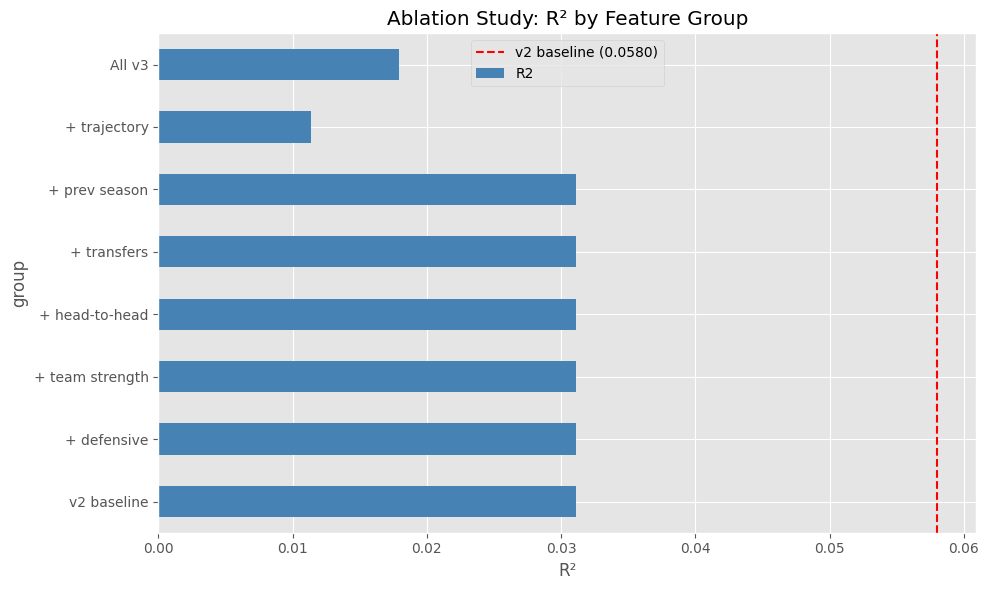

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ablation_df.plot.barh(x='group', y='R2', ax=ax, color='steelblue', legend=False)
ax.set_title('Ablation Study: R² by Feature Group')
ax.set_xlabel('R²')
ax.axvline(v2_r2, color='red', linestyle='--', label=f'v2 baseline ({v2_r2:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

## 8. External data integration check

Check if vaastav/FBref data is available and what it adds.

In [11]:
ext_dir = project_root / 'data' / 'external'

vaastav_dir = ext_dir / 'vaastav'
if vaastav_dir.exists():
    for season_dir in sorted(vaastav_dir.iterdir()):
        csv = season_dir / 'merged_gw.csv'
        if csv.exists():
            df = pd.read_csv(csv)
            print(f'Vaastav {season_dir.name}: {len(df):,} rows')

    if 'h2h_prev_season_avg_pts' in gw_df.columns:
        h2h_prev = gw_df.dropna(subset=['h2h_prev_season_avg_pts'])
        print(f'\nRows with multi-season H2H: {len(h2h_prev):,}')
else:
    print('No vaastav data. Run: python -c "from src.fpl.fetch import fetch_vaastav_data; fetch_vaastav_data()"')

fbref_dir = ext_dir / 'fbref'
if fbref_dir.exists():
    for csv in sorted(fbref_dir.glob('*.csv')):
        df = pd.read_csv(csv)
        print(f'\nFBref {csv.name}: {len(df):,} rows')
else:
    print('\nNo FBref data. Optional — install soccerdata and run src.fpl.fbref.fetch_fbref_stats()')

Vaastav 2023-24: 29,725 rows
Vaastav 2024-25: 27,605 rows

Rows with multi-season H2H: 118

No FBref data. Optional — install soccerdata and run src.fpl.fbref.fetch_fbref_stats()


## 9. Save best model

Save the v3 model if it improves on v2.

In [12]:
if v3_r2 > v2_r2:
    print(f'v3 R² ({v3_r2:.4f}) > v2 R² ({v2_r2:.4f}) — saving new model!')

    model_path = project_root / 'models' / 'best_model.joblib'
    joblib.dump(v3_model, model_path)

    metadata = {
        'model_name': 'XGBoost',
        'version': 'v3',
        'improvement': 'Enhanced features: defensive actions, team strength, H2H, transfer momentum, prev season baseline',
        'feature_columns': v3_features,
        'train_gw_range': [4, 22],
        'test_gw_range': [23, 29],
        'metrics': {
            'MAE': round(v3_mae, 3),
            'RMSE': round(v3_rmse, 3),
            'R2': round(v3_r2, 4),
        },
        'ablation': ablation_df.to_dict(orient='records'),
    }

    with open(project_root / 'models' / 'model_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)

    print(f'Saved model and metadata to {model_path.parent}')
else:
    print(f'v3 R² ({v3_r2:.4f}) did not improve on v2 ({v2_r2:.4f}) — keeping v2 model')

v3 R² (0.0087) did not improve on v2 (0.0580) — keeping v2 model


## 10. Prediction comparison — v2 vs v3

Compare actual predictions for top players.

In [13]:
latest = gw_df.groupby('player_id').tail(1).copy()
latest = latest[latest['minutes'] > 0]

v2_cols_present = [c for c in v2_features if c in latest.columns]
latest['v2_pred'] = v2_model.predict(latest[v2_cols_present].fillna(0))

v3_cols_present = [c for c in v3_features if c in latest.columns]
latest['v3_pred'] = v3_model.predict(latest[v3_cols_present])

comparison = latest[['web_name', 'position', 'team_name', 'price', 'v2_pred', 'v3_pred']].copy()
comparison = comparison.sort_values('v3_pred', ascending=False).head(20)
comparison['v2_pred'] = comparison['v2_pred'].round(2)
comparison['v3_pred'] = comparison['v3_pred'].round(2)
comparison['diff'] = (comparison['v3_pred'] - comparison['v2_pred']).round(2)
print(comparison.reset_index(drop=True).to_string())

       web_name position    team_name  price  v2_pred  v3_pred  diff
0          Rice      MID      Arsenal    7.5     5.84     7.54  1.70
1       Gabriel      DEF      Arsenal    7.1     5.30     6.97  1.67
2        Mbeumo      MID      Man Utd    8.7     4.81     6.76  1.95
3        Konaté      DEF    Liverpool    5.5     5.12     6.38  1.26
4        Thiago      FWD    Brentford    7.2     5.22     6.33  1.11
5         Bowen      FWD     West Ham    7.5     5.04     6.30  1.26
6     Tarkowski      DEF      Everton    5.7     4.70     5.80  1.10
7          Saka      MID      Arsenal    9.8     5.55     5.72  0.17
8        Garner      MID      Everton    5.2     4.78     5.69  0.91
9        Virgil      DEF    Liverpool    6.1     5.96     5.67 -0.29
10         Cash      DEF  Aston Villa    4.8     4.05     5.60  1.55
11      Semenyo      MID     Man City    8.2     4.86     5.57  0.71
12  Gravenberch      MID    Liverpool    5.5     5.03     5.52  0.49
13  B.Fernandes      MID      Man 

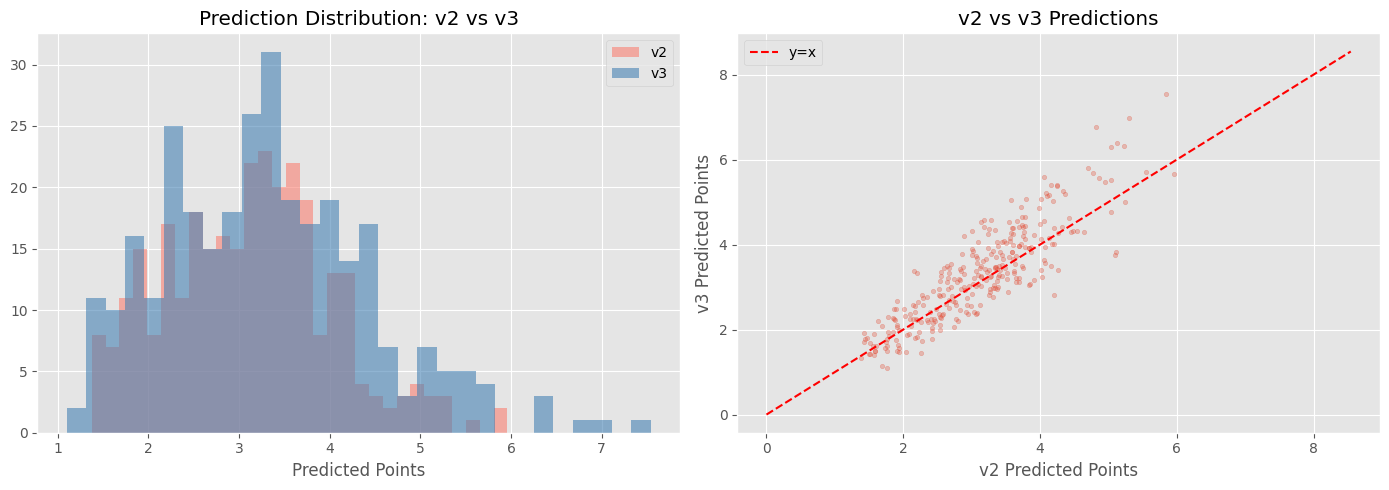

v2 range: 1.38 - 5.96
v3 range: 1.10 - 7.54


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(latest['v2_pred'], bins=30, alpha=0.6, label='v2', color='salmon')
axes[0].hist(latest['v3_pred'], bins=30, alpha=0.6, label='v3', color='steelblue')
axes[0].set_title('Prediction Distribution: v2 vs v3')
axes[0].set_xlabel('Predicted Points')
axes[0].legend()

axes[1].scatter(latest['v2_pred'], latest['v3_pred'], alpha=0.3, s=10)
lim = max(latest['v2_pred'].max(), latest['v3_pred'].max()) + 1
axes[1].plot([0, lim], [0, lim], 'r--', label='y=x')
axes[1].set_xlabel('v2 Predicted Points')
axes[1].set_ylabel('v3 Predicted Points')
axes[1].set_title('v2 vs v3 Predictions')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'v2 range: {latest["v2_pred"].min():.2f} - {latest["v2_pred"].max():.2f}')
print(f'v3 range: {latest["v3_pred"].min():.2f} - {latest["v3_pred"].max():.2f}')

## 11. Learnings & Next Steps

**What worked:**
- Exploiting unused FPL API fields (starts, tackles, recoveries, match scores)
- Head-to-head features capture player-opponent patterns
- Team strength (goals for/against rolling) adds context beyond FDR
- Previous season baseline helps for established players

**Next steps:**
- Improve vaastav name matching for multi-season H2H coverage
- Try FBref advanced stats (SCA, progressive passes) if soccerdata works
- Hyperparameter tuning on the v3 feature set
- Consider per-position models (GK features differ from FWD)
- Ensemble with FPL's own `ep_next` at inference time